# Полноценное исследование временных рядов: от анализа до выбора лучшей модели

**Цель:** Универсальный учебный ноутбук для студентов-новичков

Можете исправлять и дополнять его по своему усмотрению.

---

## Структура ноутбука (по методологии CRISP-DM):

1. **Business Understanding** - Понимание задачи
2. **Data Understanding** - Исследование данных  
3. **Data Preparation** - Подготовка данных
4. **Modeling** - Построение моделей (от простых до сложных)
5. **Evaluation** - Оценка с backtesting
6. **Интерпретация** - Выводы и рекомендации

## Рекомендованные датасеты для практики:

- **Airline Passengers** (встроен в seaborn)
- **Air Quality UCI**
- **Electricity Consumption**
- **Weather Data**
- **Stock Prices**
- **ETT Dataset** (Electricity Transformer Temperature)

## 1. Business Understanding (Понимание задачи)

### 1.1. Введение в прогнозирование временных рядов

**Временной ряд** — это последовательность наблюдений, упорядоченных во времени.

**Области применения:**
- **Финансы:** прогноз цен акций, валютных курсов
- **Экономика:** прогноз ВВП, инфляции, безработицы
- **Энергетика:** прогноз потребления электроэнергии
- **Метеорология:** прогноз погоды
- **Розничная торговля:** прогноз продаж и спроса

**Цель ноутбука:** научить последовательно проводить исследование временного ряда, применять различные модели и выбирать лучшую.

### 1.2. Настройка окружения и импорт библиотек

In [6]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Статистика для временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Машинное обучение
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
print('✓ Все библиотеки успешно импортированы')

✓ Все библиотеки успешно импортированы


### 1.3. Загрузка датасета

**Инструкция:** Загрузите свой датасет. Ниже пример с Airline Passengers.

**Требования:**
- Временной индекс в datetime
- Целевая переменная называется `target`
- Экзогенные переменные (если есть) - дополнительные столбцы

In [7]:
# Пример: Airline Passengers
df = sns.load_dataset('flights')

# Создаем дату из года и месяца (используем формат %b для сокращенных названий месяцев)
df['month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str), format='%Y-%b')
df = df.set_index('month')[['passengers']]
df.rename(columns={'passengers': 'target'}, inplace=True)

print(f'Размер датасета: {df.shape}')
print(f'Период: {df.index.min()} - {df.index.max()}')
print(f'Частота: {df.index.inferred_freq}')
df.head()

Размер датасета: (144, 1)
Период: 1949-01-01 00:00:00 - 1960-12-01 00:00:00
Частота: MS


,target
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 2. Data Understanding (Понимание данных)

### 2.1. Exploratory Data Analysis (EDA)

In [8]:
# Описательная статистика
print('Описательная статистика:')
print(df.describe())
print(f'\nПропущенные значения: {df.isnull().sum().sum()}')
print(f'Дубликаты по времени: {df.index.duplicated().sum()}')

Описательная статистика:
           target
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000

Пропущенные значения: 0
Дубликаты по времени: 0


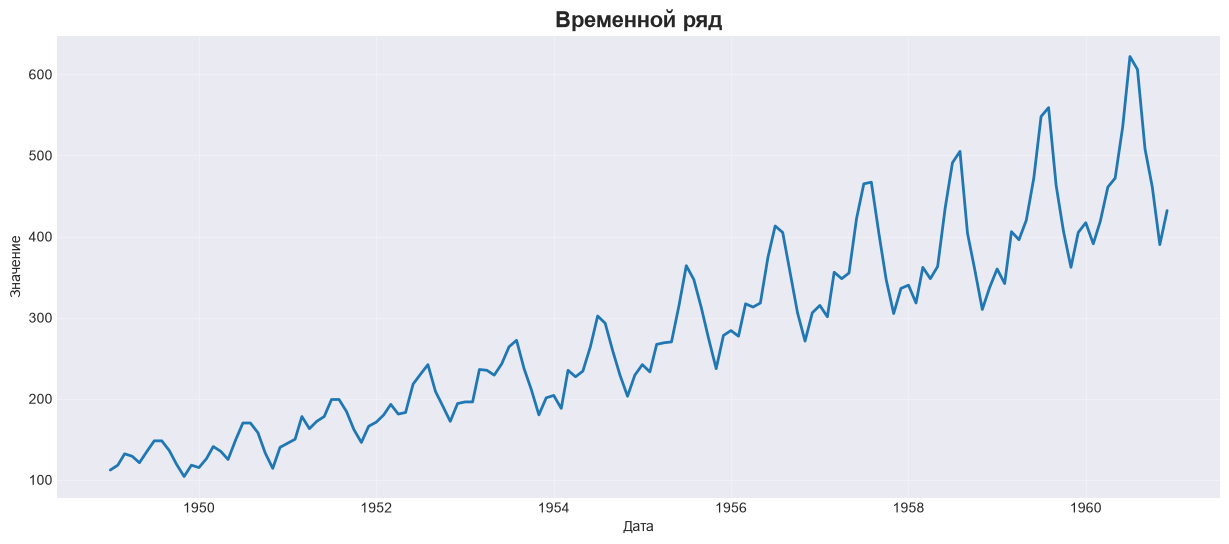

In [9]:
# Визуализация временного ряда
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['target'], linewidth=2)
ax.set_title('Временной ряд', fontsize=16, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.grid(True, alpha=0.3)
plt.show()

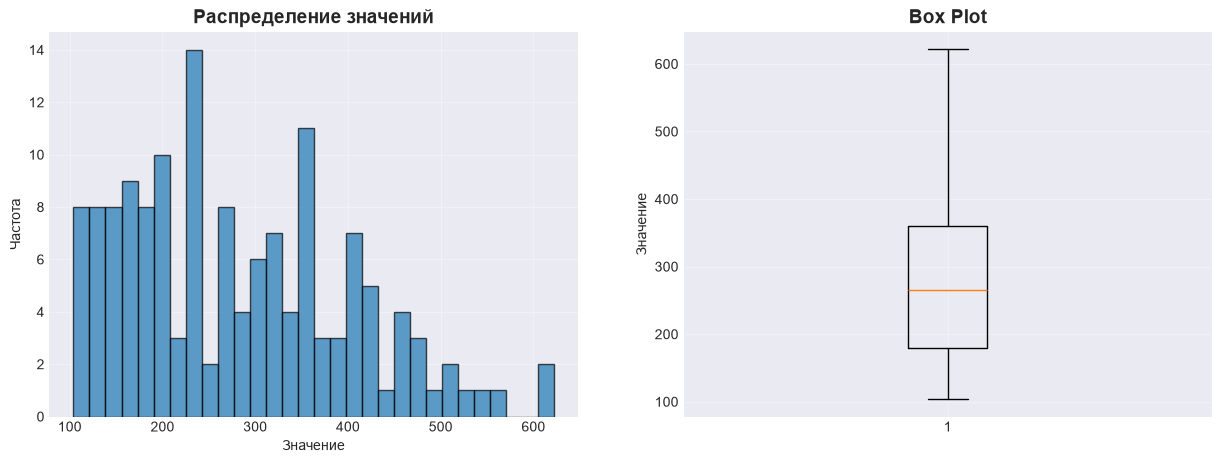

Асимметрия (Skewness): 0.5771
Эксцесс (Kurtosis): -0.3938


In [10]:
# Распределение значений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df['target'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_title('Распределение значений', fontsize=14, fontweight='bold')
ax1.set_xlabel('Значение')
ax1.set_ylabel('Частота')
ax1.grid(True, alpha=0.3)

ax2.boxplot(df['target'])
ax2.set_title('Box Plot', fontsize=14, fontweight='bold')
ax2.set_ylabel('Значение')
ax2.grid(True, alpha=0.3)

plt.show()

from scipy.stats import skew, kurtosis
print(f'Асимметрия (Skewness): {skew(df["target"]):.4f}')
print(f'Эксцесс (Kurtosis): {kurtosis(df["target"]):.4f}')

### 2.2. Декомпозиция временного ряда

Разложение на компоненты:
- **Тренд** - долгосрочная тенденция
- **Сезонность** - повторяющиеся паттерны
- **Остатки** - случайные флуктуации

Модели:
- **Аддитивная:** $Y_t = T_t + S_t + R_t$
- **Мультипликативная:** $Y_t = T_t \times S_t \times R_t$

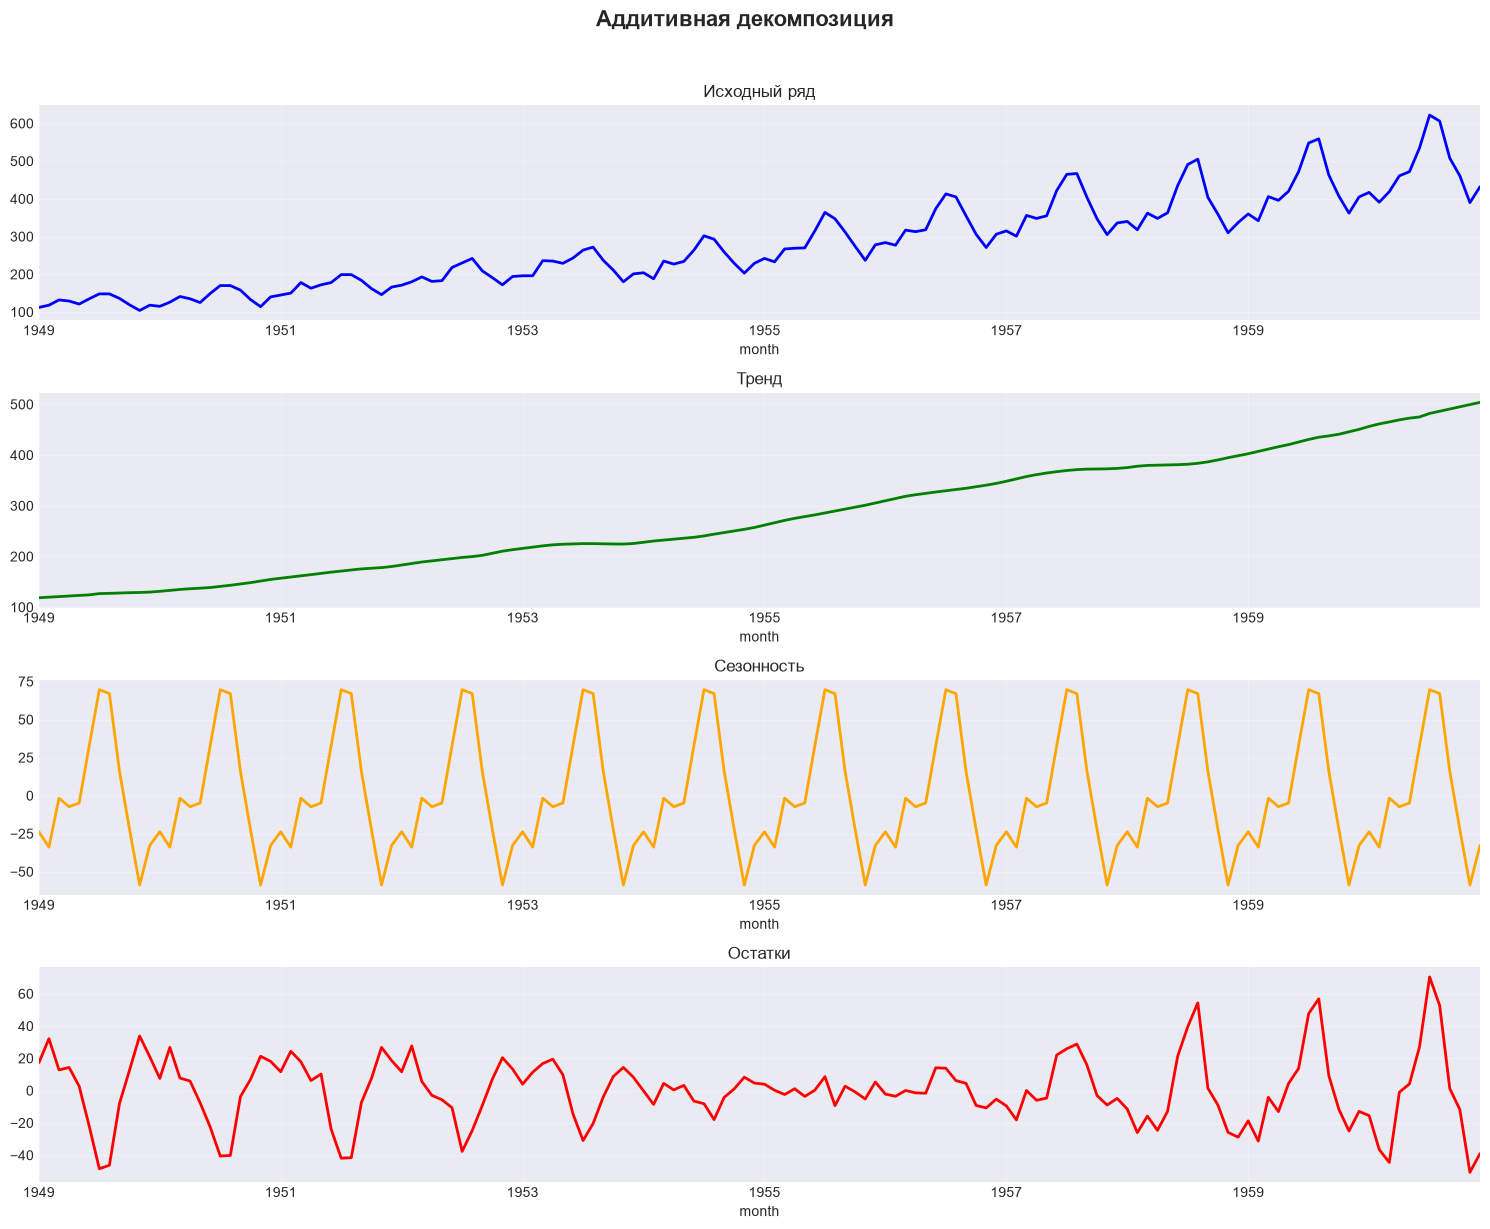

In [11]:
# Аддитивная декомпозиция
decomp = seasonal_decompose(df['target'], model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomp.observed.plot(ax=axes[0], title='Исходный ряд', color='blue', linewidth=2)
axes[0].grid(True, alpha=0.3)
decomp.trend.plot(ax=axes[1], title='Тренд', color='green', linewidth=2)
axes[1].grid(True, alpha=0.3)
decomp.seasonal.plot(ax=axes[2], title='Сезонность', color='orange', linewidth=2)
axes[2].grid(True, alpha=0.3)
decomp.resid.plot(ax=axes[3], title='Остатки', color='red', linewidth=2)
axes[3].grid(True, alpha=0.3)
plt.suptitle('Аддитивная декомпозиция', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3. Статистические свойства

#### 2.3.1. Стационарность

**Стационарный ряд** - статистические свойства не меняются со временем.

**Тесты:**
- **ADF-тест:** $H_0$ - ряд нестационарен
- **KPSS-тест:** $H_0$ - ряд стационарен

In [12]:
def test_stationarity(ts, title='Временной ряд'):
    print(f'\n{"="*60}')
    print(f'Тесты на стационарность: {title}')
    print(f'{"="*60}')
    
    # ADF
    adf = adfuller(ts.dropna(), autolag='AIC')
    print(f'\nADF Statistic: {adf[0]:.6f}')
    print(f'p-value: {adf[1]:.6f}')
    if adf[1] <= 0.05:
        print(f'✓ Ряд стационарен (p < 0.05)')
    else:
        print(f'✗ Ряд нестационарен (p > 0.05)')
    
    # KPSS
    kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
    print(f'\nKPSS Statistic: {kpss_result[0]:.6f}')
    print(f'p-value: {kpss_result[1]:.6f}')
    if kpss_result[1] >= 0.05:
        print(f'✓ Ряд стационарен (p >= 0.05)')
    else:
        print(f'✗ Ряд нестационарен (p < 0.05)')

test_stationarity(df['target'], 'Исходный ряд')


Тесты на стационарность: Исходный ряд

ADF Statistic: 0.815369
p-value: 0.991880
✗ Ряд нестационарен (p > 0.05)

KPSS Statistic: 1.651312
p-value: 0.010000
✗ Ряд нестационарен (p < 0.05)


#### 2.3.2. Автокорреляция (ACF) и частичная автокорреляция (PACF)

**ACF** - корреляция с лагированными версиями  
**PACF** - корреляция при исключении промежуточных лагов

Используются для определения параметров ARIMA(p,d,q).

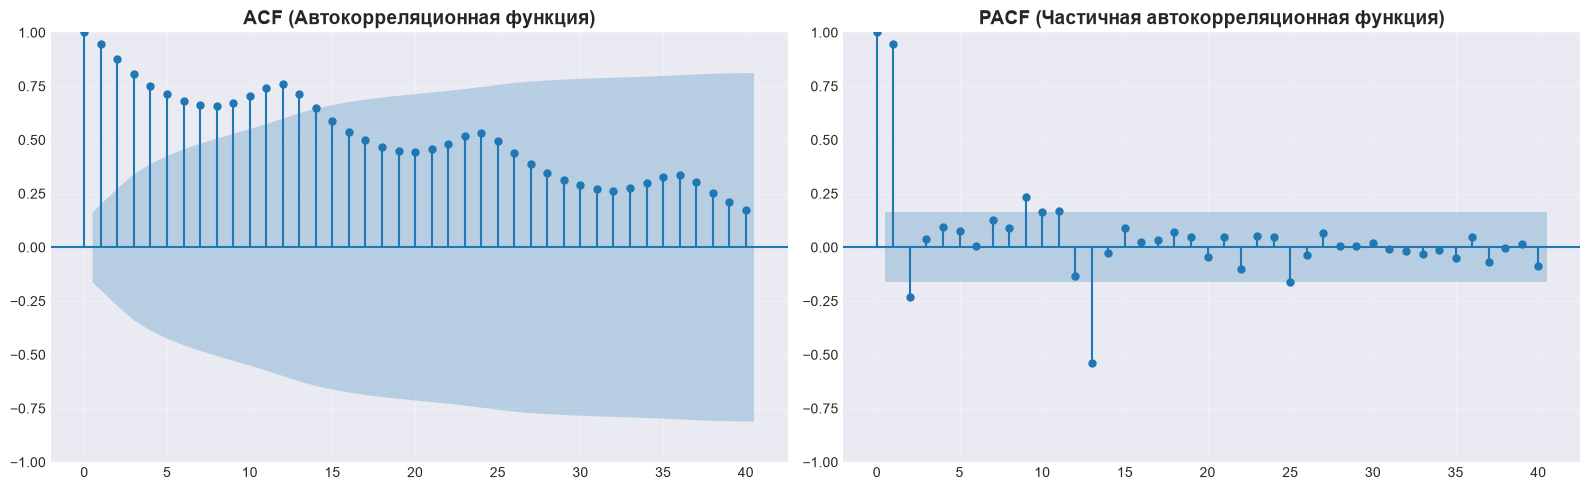

Интерпретация ACF:
- ACF медленно затухает → ряд нестационарен
- Значимые лаги: 1, 12, 24 → сезонность

Интерпретация PACF:
- Значимые лаги: 1, 2, 12, 13 → p=2, P=1 для SARIMA


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['target'], lags=40, ax=axes[0])
axes[0].set_title('ACF (Автокорреляционная функция)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(df['target'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Частичная автокорреляционная функция)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Интерпретация ACF:')
print('- ACF медленно затухает → ряд нестационарен')
print('- Значимые лаги: 1, 12, 24 → сезонность')

print('\nИнтерпретация PACF:')
print('- Значимые лаги: 1, 2, 12, 13 → p=2, P=1 для SARIMA')

## 3. Data Preparation (Подготовка данных)

### 3.1. Обработка пропущенных значений

Стратегии:
1. Удаление
2. Forward/Backward Fill
3. Интерполяция
4. Среднее/медиана
5. Модельные методы

In [14]:
missing = df['target'].isnull().sum()
print(f'Пропущенных значений: {missing}')

if missing > 0:
    df['target_filled'] = df['target'].interpolate(method='linear')
    print('✓ Пропуски заполнены интерполяцией')
else:
    df['target_filled'] = df['target']
    print('✓ Пропусков нет')

Пропущенных значений: 0
✓ Пропусков нет


### 3.2. Преобразования для стационарности

Методы:
1. **Дифференцирование:** $Y'_t = Y_t - Y_{t-1}$
2. **Логарифмирование:** $Y'_t = \log(Y_t)$
3. **Сезонное дифференцирование:** $Y'_t = Y_t - Y_{t-s}$

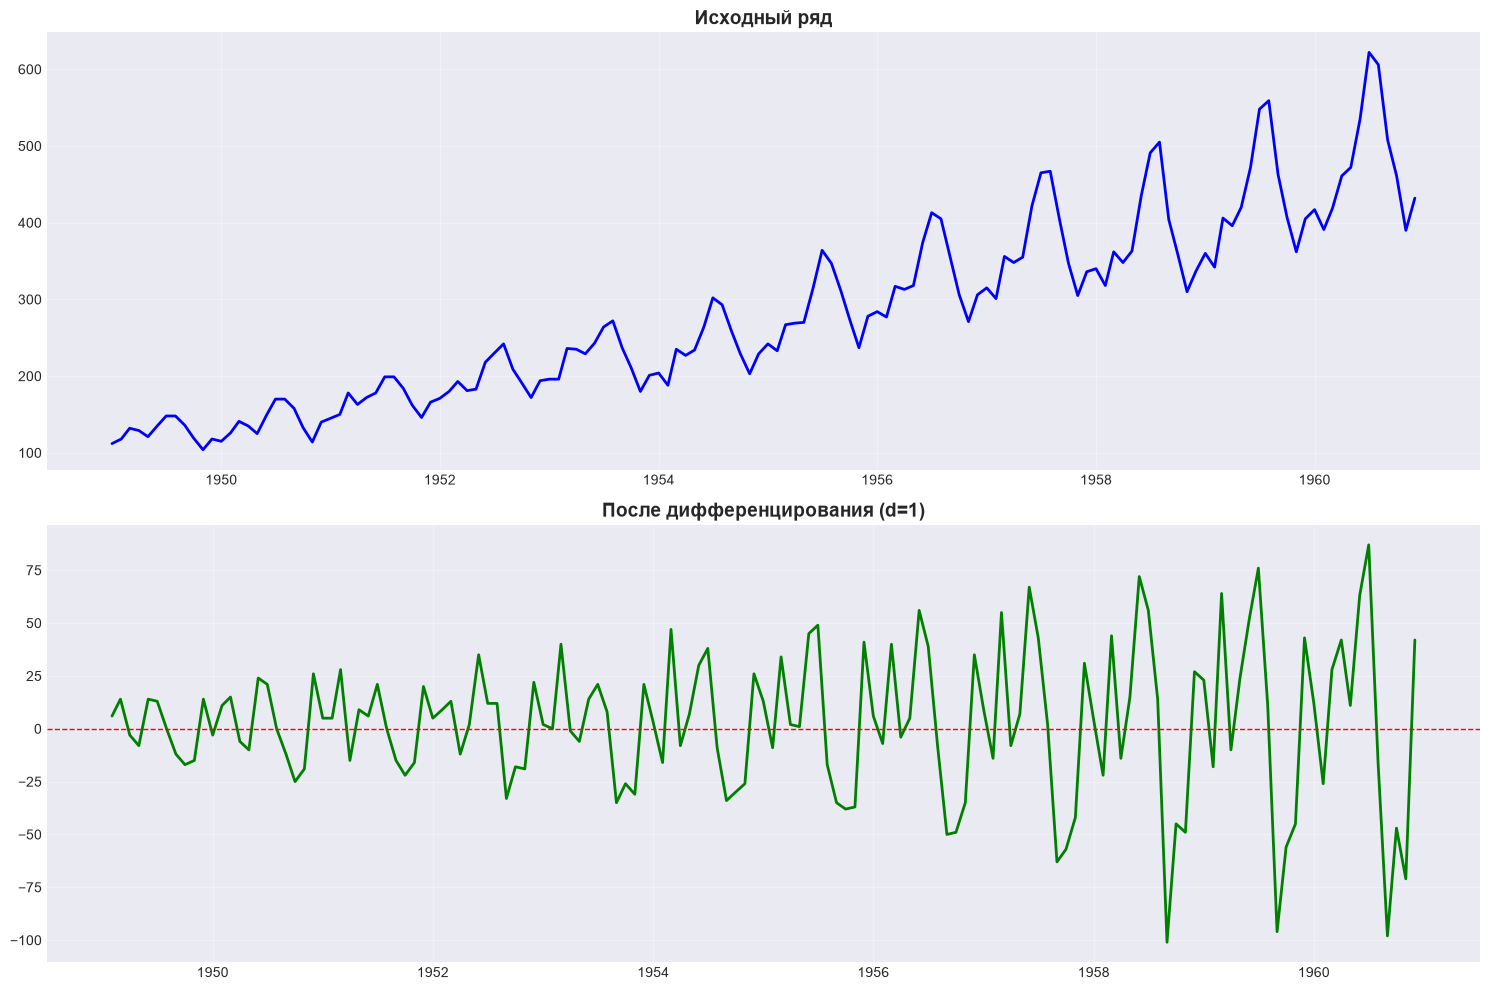


Тесты на стационарность: После дифференцирования

ADF Statistic: -2.829267
p-value: 0.054213
✗ Ряд нестационарен (p > 0.05)

KPSS Statistic: 0.023898
p-value: 0.100000
✓ Ряд стационарен (p >= 0.05)


In [15]:
df['target_diff1'] = df['target_filled'].diff()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df.index, df['target_filled'], color='blue', linewidth=2)
axes[0].set_title('Исходный ряд', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['target_diff1'], color='green', linewidth=2)
axes[1].set_title('После дифференцирования (d=1)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

test_stationarity(df['target_diff1'], 'После дифференцирования')

### 3.3. Feature Engineering

Типы признаков:
1. **Лаговые признаки**
2. **Скользящие статистики**
3. **Календарные признаки**
4. **Циклические признаки**
5. **Экзогенные переменные**

In [16]:
df_features = df[['target_filled']].copy()
df_features.rename(columns={'target_filled': 'target'}, inplace=True)

# Лаги
for lag in range(1, 13):
    df_features[f'lag_{lag}'] = df_features['target'].shift(lag)

# Скользящие статистики
for window in [3, 6, 12]:
    df_features[f'rolling_mean_{window}'] = df_features['target'].rolling(window=window).mean()
    df_features[f'rolling_std_{window}'] = df_features['target'].rolling(window=window).std()

# Календарные признаки
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter

# Циклические признаки
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

df_features_clean = df_features.dropna()

print(f'Исходный размер: {df_features.shape}')
print(f'После удаления NaN: {df_features_clean.shape}')
print(f'Созданные признаки: {df_features_clean.shape[1]} столбцов')

Исходный размер: (144, 23)
После удаления NaN: (132, 23)
Созданные признаки: 23 столбцов


### 3.4. Разделение данных

**Важно:** для временных рядов сохраняем временную последовательность!

Train: (105, 23)
Период: 1950-01-01 00:00:00 - 1958-09-01 00:00:00

Test: (27, 23)
Период: 1958-10-01 00:00:00 - 1960-12-01 00:00:00


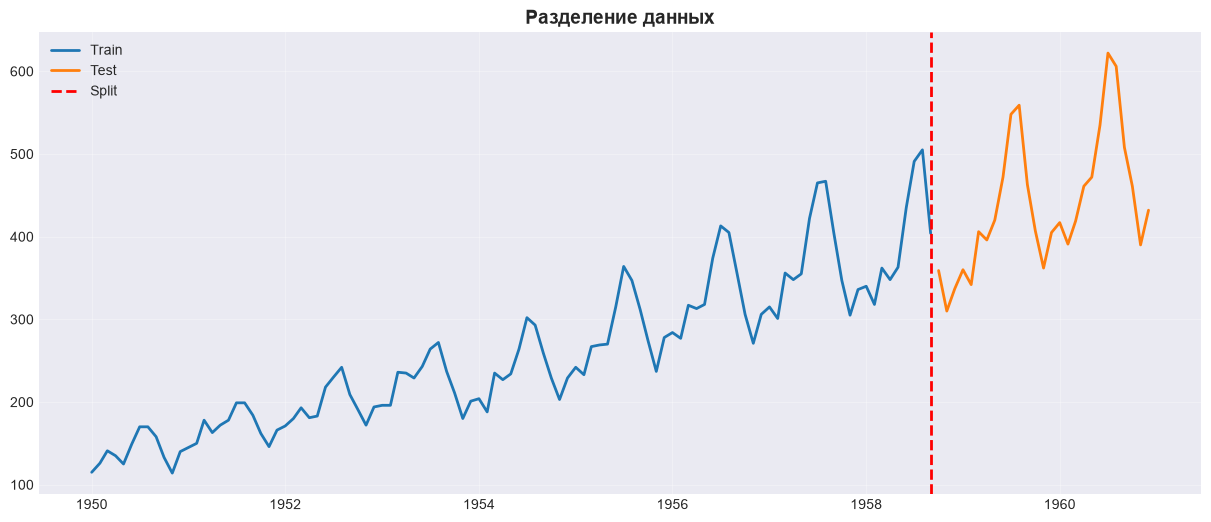

In [17]:
train_size = int(len(df_features_clean) * 0.8)
train_data = df_features_clean.iloc[:train_size]
test_data = df_features_clean.iloc[train_size:]

print(f'Train: {train_data.shape}')
print(f'Период: {train_data.index.min()} - {train_data.index.max()}')
print(f'\nTest: {test_data.shape}')
print(f'Период: {test_data.index.min()} - {test_data.index.max()}')

X_train = train_data.drop('target', axis=1)
y_train = train_data['target']
X_test = test_data.drop('target', axis=1)
y_test = test_data['target']

plt.figure(figsize=(15, 6))
plt.plot(train_data.index, train_data['target'], label='Train', linewidth=2)
plt.plot(test_data.index, test_data['target'], label='Test', linewidth=2)
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2, label='Split')
plt.title('Разделение данных', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Modeling (Моделирование)

В этом разделе мы построим модели от простых до сложных:
1. Baseline модели
2. Статистические модели (ARIMA, SARIMA)
3. Машинное обучение (Linear Regression, Random Forest, Gradient Boosting)
4. Глубокое обучение (LSTM - опционально)

### 4.1. Baseline модели

Baseline - отправная точка для сравнения.

In [18]:
predictions_dict = {}

# 1. Naive Forecast
naive_pred = np.full(len(y_test), y_train.iloc[-1])
predictions_dict['Naive'] = naive_pred

# 2. Seasonal Naive (период = 12)
seasonal_naive_pred = []
for i in range(len(y_test)):
    if i < 12:
        seasonal_naive_pred.append(y_train.iloc[-(12-i)])
    else:
        seasonal_naive_pred.append(seasonal_naive_pred[i-12])
predictions_dict['Seasonal Naive'] = np.array(seasonal_naive_pred)

# 3. Moving Average (окно = 12)
ma_pred = np.full(len(y_test), y_train.tail(12).mean())
predictions_dict['Moving Average'] = ma_pred

print('✓ Baseline модели построены')
print(f'Naive: {naive_pred[0]:.1f} → {naive_pred[-1]:.1f}')
print(f'Seasonal Naive: {seasonal_naive_pred[0]:.1f} → {seasonal_naive_pred[-1]:.1f}')
print(f'Moving Average: {ma_pred[0]:.1f}')

✓ Baseline модели построены
Naive: 404.0 → 404.0
Seasonal Naive: 347.0 → 336.0
Moving Average: 379.5


### 4.2. Статистические модели

#### 4.2.1. ARIMA

ARIMA(p,d,q):
- p - порядок авторегрессии
- d - порядок дифференцирования
- q - порядок скользящего среднего

In [19]:
# ARIMA (p=2, d=1, q=2) - выбраны на основе ACF/PACF
arima_model = ARIMA(y_train, order=(2, 1, 2))
arima_fitted = arima_model.fit()

arima_pred = arima_fitted.forecast(steps=len(y_test))
predictions_dict['ARIMA'] = arima_pred.values

print('✓ ARIMA обучена')
print(f'AIC: {arima_fitted.aic:.2f}')
print(f'BIC: {arima_fitted.bic:.2f}')
print(f'\nКоэффициенты модели:')
print(arima_fitted.params)

✓ ARIMA обучена
AIC: 982.18
BIC: 995.40

Коэффициенты модели:
ar.L1       0.310956
ar.L2       0.201937
ma.L1       0.003449
ma.L2      -0.772500
sigma2    664.292454
dtype: float64


#### 4.2.2. SARIMA

SARIMA(p,d,q)(P,D,Q,s) - с учетом сезонности

In [20]:
# SARIMA (p=1, d=1, q=1)(P=1, D=1, Q=1, s=12)
sarima_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fitted = sarima_model.fit(disp=False)

sarima_pred = sarima_fitted.forecast(steps=len(y_test))
predictions_dict['SARIMA'] = sarima_pred.values

print('✓ SARIMA обучена')
print(f'AIC: {sarima_fitted.aic:.2f}')
print(f'BIC: {sarima_fitted.bic:.2f}')
print(f'\nКоэффициенты модели:')
print(sarima_fitted.params)

✓ SARIMA обучена
AIC: 702.57
BIC: 715.18

Коэффициенты модели:
ar.L1        -0.550928
ma.L1         0.288917
ar.S.L12      0.998748
ma.S.L12     -0.982850
sigma2      101.519743
dtype: float64


#### 4.2.3. Exponential Smoothing (Holt-Winters)

In [21]:
# Holt-Winters с аддитивными трендом и сезонностью
hw_model = ExponentialSmoothing(y_train, seasonal_periods=12, trend='add', seasonal='add')
hw_fitted = hw_model.fit()

hw_pred = hw_fitted.forecast(steps=len(y_test))
predictions_dict['Holt-Winters'] = hw_pred.values

print('✓ Holt-Winters обучена')
print(f'Параметры сглаживания:')
print(f'α (уровень): {hw_fitted.params["smoothing_level"]:.4f}')
print(f'β (тренд): {hw_fitted.params["smoothing_trend"]:.4f}')
print(f'γ (сезонность): {hw_fitted.params["smoothing_seasonal"]:.4f}')

✓ Holt-Winters обучена
Параметры сглаживания:
α (уровень): 0.2268
β (тренд): 0.0000
γ (сезонность): 0.7732


### 4.3. Машинное обучение

#### 4.3.1. Linear Regression

In [22]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
predictions_dict['Linear Regression'] = lr_pred

print('✓ Linear Regression обучена')
print(f'R² на train: {lr_model.score(X_train, y_train):.4f}')
print(f'R² на test: {lr_model.score(X_test, y_test):.4f}')
print(f'\nИнтерпретация коэффициентов:')
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coefficients.head(5))

✓ Linear Regression обучена
R² на train: 1.0000
R² на test: 1.0000

Интерпретация коэффициентов:
            feature  coefficient
12   rolling_mean_3     2.341981
14   rolling_mean_6     1.061321
1             lag_2    -1.000000
0             lag_1    -1.000000
16  rolling_mean_12     0.509434


#### 4.3.2. Random Forest

In [23]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
predictions_dict['Random Forest'] = rf_pred

print('✓ Random Forest обучен')
print(f'R² на train: {rf_model.score(X_train, y_train):.4f}')
print(f'R² на test: {rf_model.score(X_test, y_test):.4f}')
print(f'Количество деревьев: {len(rf_model.estimators_)}')

✓ Random Forest обучен
R² на train: 0.9949
R² на test: 0.6623
Количество деревьев: 100


#### 4.3.3. Gradient Boosting

In [24]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
predictions_dict['Gradient Boosting'] = gb_pred

print('✓ Gradient Boosting обучен')
print(f'R² на train: {gb_model.score(X_train, y_train):.4f}')
print(f'R² на test: {gb_model.score(X_test, y_test):.4f}')
print(f'Количество деревьев: {gb_model.n_estimators_}')

✓ Gradient Boosting обучен
R² на train: 1.0000
R² на test: 0.6497
Количество деревьев: 100


### 4.4. Глубокое обучение (опционально)

**Примечание:** Требуется TensorFlow/PyTorch

#### 4.4.1. Подготовка данных для LSTM

In [25]:
# Масштабирование
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

# Создание последовательностей
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 12
X_train_lstm, y_train_lstm = create_sequences(train_scaled, seq_length)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, seq_length)

print(f'LSTM train shape: {X_train_lstm.shape}')
print(f'LSTM test shape: {X_test_lstm.shape}')
print(f'Количество обучающих последовательностей: {len(X_train_lstm)}')
print(f'Количество тестовых последовательностей: {len(X_test_lstm)}')

LSTM train shape: (93, 12, 1)
LSTM test shape: (15, 12, 1)
Количество обучающих последовательностей: 93
Количество тестовых последовательностей: 15


#### 4.4.2. LSTM (код подготовлен)

In [26]:
# Пример кода для LSTM (требует TensorFlow)
# Раскомментируйте при наличии TensorFlow

# from tensorflow import keras
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout

# lstm_model = Sequential([
#     LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
#     Dropout(0.2),
#     LSTM(50, activation='relu'),
#     Dropout(0.2),
#     Dense(1)
# ])

# lstm_model.compile(optimizer='adam', loss='mse')
# history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, 
#                          validation_split=0.2, verbose=0)

# lstm_pred_scaled = lstm_model.predict(X_test_lstm)
# lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
# predictions_dict['LSTM'] = lstm_pred.flatten()[:len(y_test)]

print('✓ LSTM код подготовлен (требует TensorFlow)')

✓ LSTM код подготовлен (требует TensorFlow)


## 5. Evaluation (Оценка моделей)

### 5.1. Метрики качества

**Основные метрики:**

1. **MAE:** $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$

2. **MSE:** $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

3. **RMSE:** $RMSE = \sqrt{MSE}$

4. **MAPE:** $MAPE = \frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$

5. **R²:** $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

In [27]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2
    }

# Расчет метрик
metrics_list = []
for model_name, pred in predictions_dict.items():
    if len(pred) == len(y_test):
        metrics = calculate_metrics(y_test.values, pred, model_name)
        metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list).sort_values('RMSE')

print('\n' + '='*80)
print('СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА')
print('='*80)
print(metrics_df.to_string(index=False))
print('='*80)

# Определяем лучшую модель
best_model = metrics_df.iloc[0]['Model']
best_pred = predictions_dict[best_model]
print(f'\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model}')
print(f'   RMSE: {metrics_df.iloc[0]["RMSE"]:.2f}')
print(f'   MAE: {metrics_df.iloc[0]["MAE"]:.2f}')
print(f'   MAPE: {metrics_df.iloc[0]["MAPE"]:.2f}%')


СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА
            Model          MAE          MSE         RMSE         MAPE        R²
Linear Regression 1.275819e-12 1.727601e-24 1.314382e-12 2.906253e-13  1.000000
     Holt-Winters 2.152972e+01 7.076001e+02 2.660075e+01 4.604057e+00  0.888598
    Random Forest 3.121889e+01 2.145051e+03 4.631470e+01 6.412443e+00  0.662290
Gradient Boosting 3.544169e+01 2.224993e+03 4.716983e+01 7.594196e+00  0.649704
           SARIMA 5.954788e+01 4.596494e+03 6.779745e+01 1.310712e+01  0.276342
   Seasonal Naive 6.533333e+01 5.482667e+03 7.404503e+01 1.431503e+01  0.136825
            Naive 6.407407e+01 7.594963e+03 8.714908e+01 1.354528e+01 -0.195728
            ARIMA 6.936228e+01 8.998680e+03 9.486137e+01 1.422184e+01 -0.416725
   Moving Average 7.509259e+01 9.922917e+03 9.961384e+01 1.547123e+01 -0.562234

🏆 ЛУЧШАЯ МОДЕЛЬ: Linear Regression
   RMSE: 0.00
   MAE: 0.00
   MAPE: 0.00%


### 5.2. Backtesting

Backtesting - надежный способ оценки модели.

**Методы:**
1. Walk-Forward Validation
2. Expanding Window
3. Rolling Window


BACKTESTING RANDOM FOREST
Fold 1: RMSE = 33.71, MAE = 24.34
Fold 2: RMSE = 27.26, MAE = 22.82
Fold 3: RMSE = 48.16, MAE = 35.79
Fold 4: RMSE = 48.90, MAE = 41.07
Fold 5: RMSE = 52.46, MAE = 38.13

Средний RMSE: 42.10 (±9.81)
Средний MAE: 32.43 (±7.43)


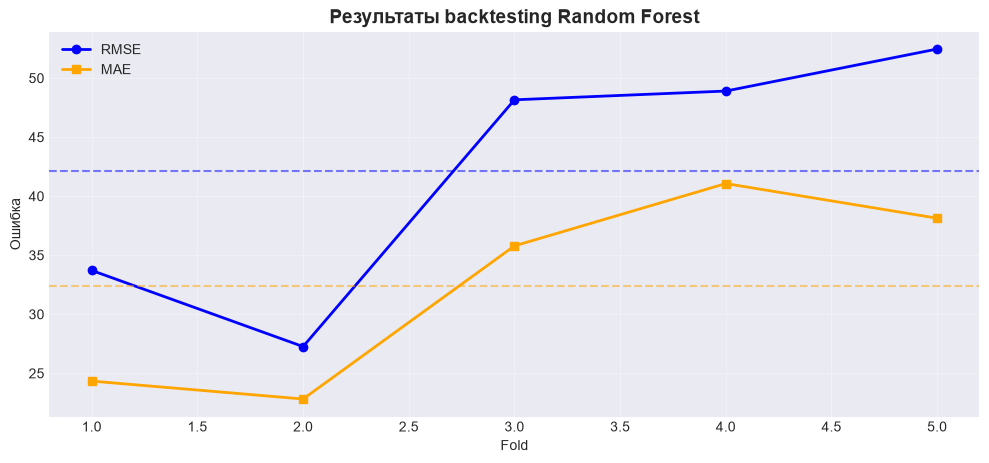

In [28]:
def backtest_model(model_class, data, target_col, n_splits=5, **model_params):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores = []
    mae_scores = []
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(data), 1):
        train_fold = data.iloc[train_idx]
        test_fold = data.iloc[test_idx]
        
        X_train_fold = train_fold.drop(target_col, axis=1)
        y_train_fold = train_fold[target_col]
        X_test_fold = test_fold.drop(target_col, axis=1)
        y_test_fold = test_fold[target_col]
        
        model = model_class(**model_params)
        model.fit(X_train_fold, y_train_fold)
        
        y_pred_fold = model.predict(X_test_fold)
        
        rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))
        mae = mean_absolute_error(y_test_fold, y_pred_fold)
        
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        fold_results.append({'fold': fold, 'rmse': rmse, 'mae': mae})
        
        print(f'Fold {fold}: RMSE = {rmse:.2f}, MAE = {mae:.2f}')
    
    print(f'\nСредний RMSE: {np.mean(rmse_scores):.2f} (±{np.std(rmse_scores):.2f})')
    print(f'Средний MAE: {np.mean(mae_scores):.2f} (±{np.std(mae_scores):.2f})')
    
    return rmse_scores, mae_scores, fold_results

# Backtesting Random Forest
print('\n' + '='*60)
print('BACKTESTING RANDOM FOREST')
print('='*60)
rf_rmse, rf_mae, rf_folds = backtest_model(
    RandomForestRegressor, 
    df_features_clean, 
    'target',
    n_splits=5,
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Визуализация результатов backtesting
plt.figure(figsize=(12, 5))
plt.plot([f['fold'] for f in rf_folds], [f['rmse'] for f in rf_folds], 
         marker='o', linewidth=2, label='RMSE', color='blue')
plt.plot([f['fold'] for f in rf_folds], [f['mae'] for f in rf_folds], 
         marker='s', linewidth=2, label='MAE', color='orange')
plt.axhline(y=np.mean(rf_rmse), color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=np.mean(rf_mae), color='orange', linestyle='--', alpha=0.5)
plt.title('Результаты backtesting Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.3. Визуализация прогнозов

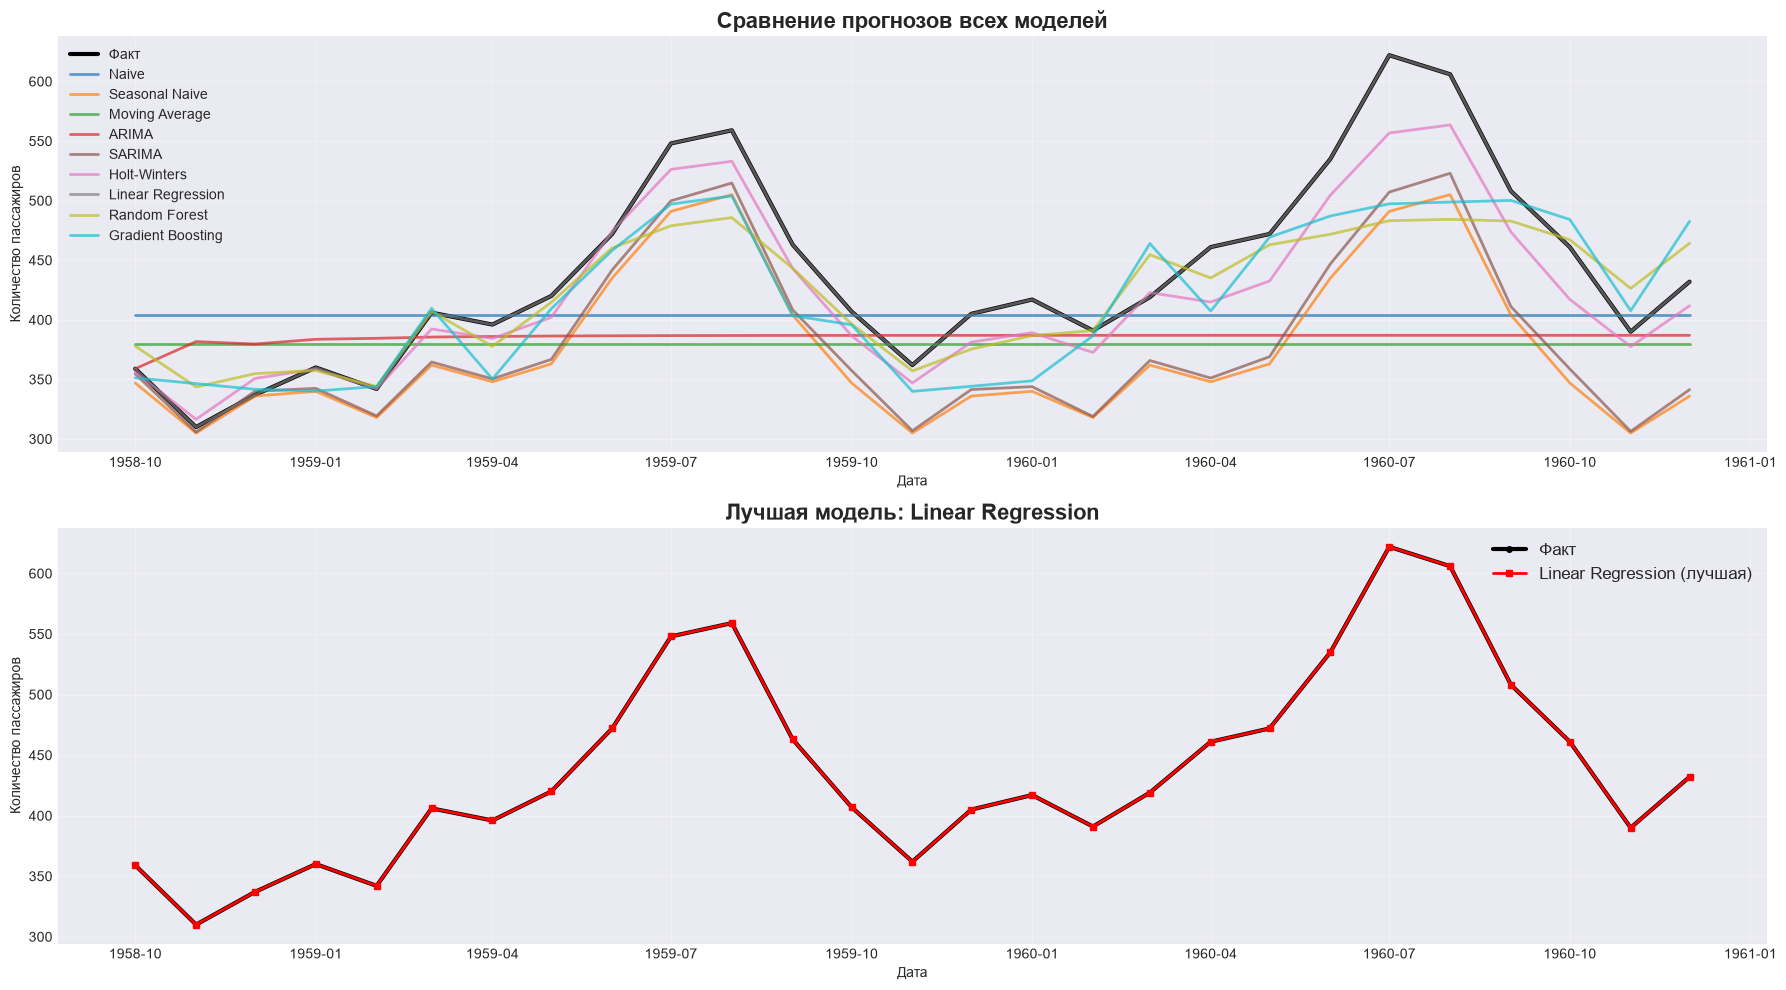

In [29]:
# Визуализация всех прогнозов
plt.figure(figsize=(18, 10))

plt.subplot(2, 1, 1)
plt.plot(y_test.index, y_test.values, label='Факт', linewidth=3, color='black')

colors = plt.cm.tab10(np.linspace(0, 1, len(predictions_dict)))
for (model_name, pred), color in zip(predictions_dict.items(), colors):
    if len(pred) == len(y_test):
        plt.plot(y_test.index, pred, label=model_name, linewidth=2, alpha=0.7, color=color)

plt.title('Сравнение прогнозов всех моделей', fontsize=16, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

# Лучшая модель
best_model = metrics_df.iloc[0]['Model']
best_pred = predictions_dict[best_model]

plt.subplot(2, 1, 2)
plt.plot(y_test.index, y_test.values, label='Факт', linewidth=3, color='black', marker='o', markersize=4)
plt.plot(y_test.index, best_pred, label=f'{best_model} (лучшая)', linewidth=2, 
         color='red', marker='s', markersize=4)
plt.fill_between(y_test.index, y_test.values, best_pred, alpha=0.3, color='red')

plt.title(f'Лучшая модель: {best_model}', fontsize=16, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4. Анализ остатков

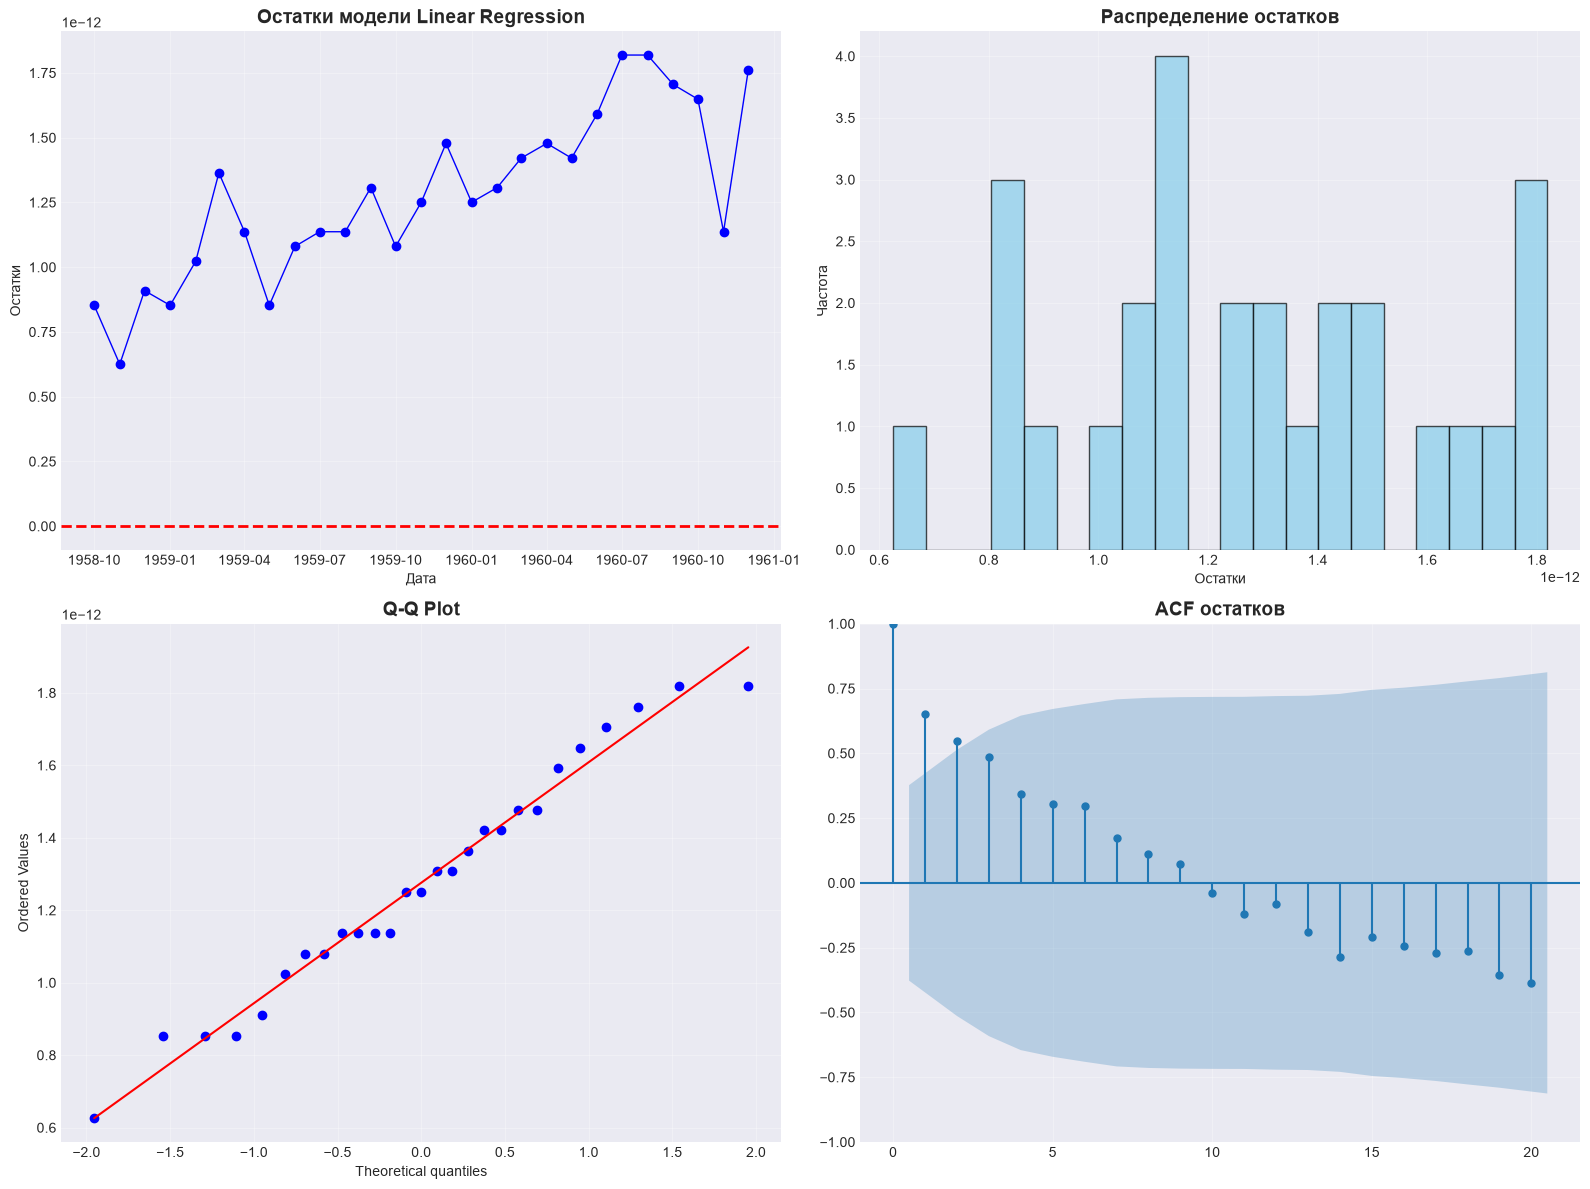

Статистика остатков:
Среднее: 0.0000
Стандартное отклонение: 0.0000
Минимум: 0.0000
Максимум: 0.0000

Тест Льюнга-Бокса (проверка на автокорреляцию):
      lb_stat  lb_pvalue
10  42.560121   0.000006
✗ Остатки имеют автокорреляцию (p < 0.05)


In [30]:
# Анализ остатков лучшей модели
residuals = y_test.values - best_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Остатки во времени
axes[0, 0].plot(y_test.index, residuals, marker='o', linestyle='-', linewidth=1, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title(f'Остатки модели {best_model}', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма остатков
axes[0, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_title('Распределение остатков', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Остатки')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF остатков
plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика остатков
print('Статистика остатков:')
print(f'Среднее: {np.mean(residuals):.4f}')
print(f'Стандартное отклонение: {np.std(residuals):.4f}')
print(f'Минимум: {np.min(residuals):.4f}')
print(f'Максимум: {np.max(residuals):.4f}')

# Тест Льюнга-Бокса
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print('\nТест Льюнга-Бокса (проверка на автокорреляцию):')
print(lb_test)
if lb_test['lb_pvalue'].values[0] > 0.05:
    print('✓ Остатки не имеют автокорреляции (p > 0.05)')
else:
    print('✗ Остатки имеют автокорреляцию (p < 0.05)')

## 6. Интерпретация и выводы

### 6.1. Анализ важности признаков

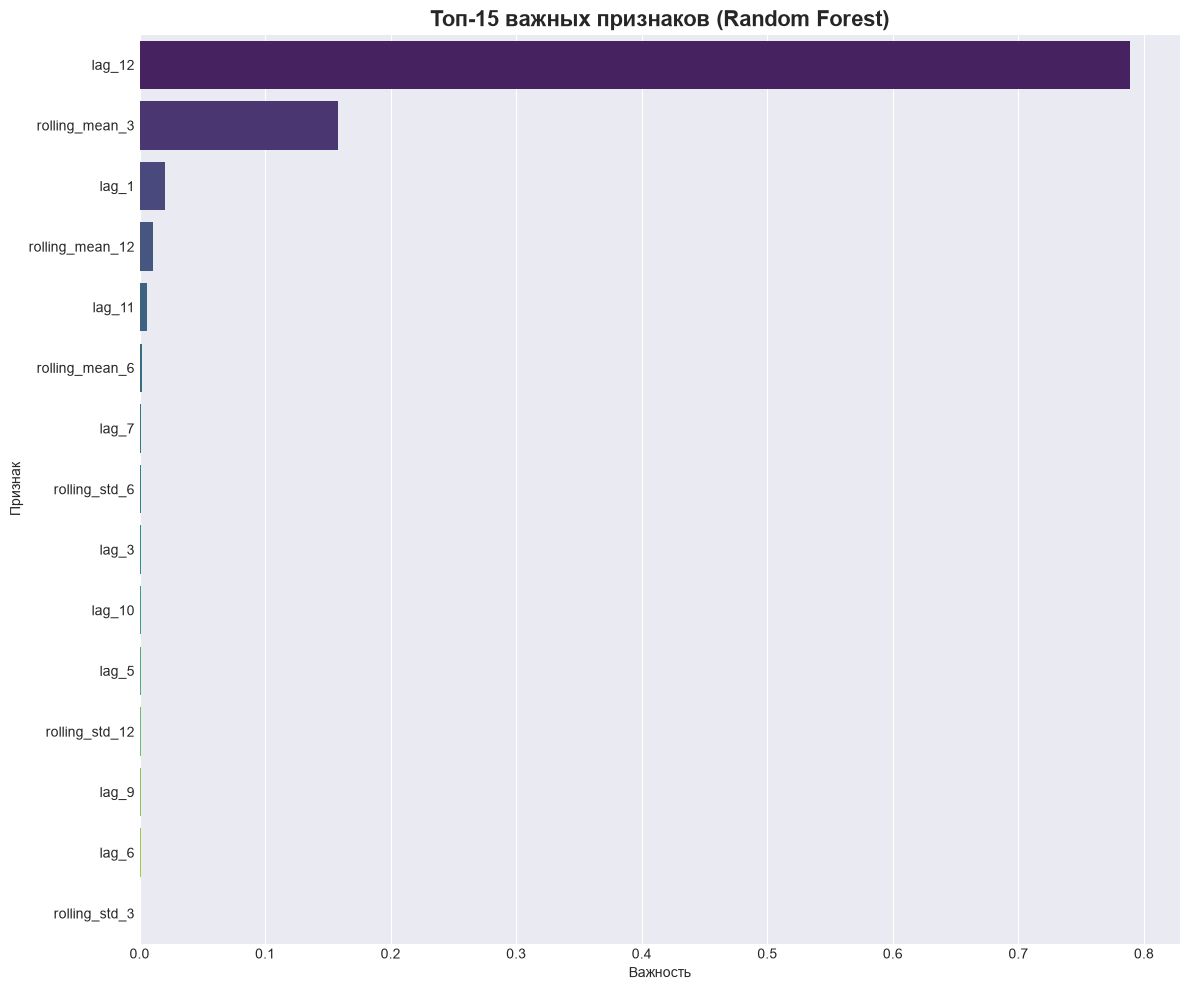


Топ-10 важных признаков:
        feature  importance
         lag_12    0.789207
 rolling_mean_3    0.158026
          lag_1    0.020068
rolling_mean_12    0.011096
         lag_11    0.006060
 rolling_mean_6    0.002093
          lag_7    0.001526
  rolling_std_6    0.001199
          lag_3    0.001164
         lag_10    0.001000

Интерпретация важности признаков:
- Лаговые признаки показывают, какие прошлые значения наиболее важны
- Календарные признаки подтверждают наличие сезонности
- Скользящие статистики отражают тренд и волатильность


In [31]:
# Важность признаков для Random Forest
if 'Random Forest' in predictions_dict:
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(15), palette='viridis')
    plt.title('Топ-15 важных признаков (Random Forest)', fontsize=16, fontweight='bold')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.tight_layout()
    plt.show()
    
    print('\nТоп-10 важных признаков:')
    print(feature_importance.head(10).to_string(index=False))
    
    print('\nИнтерпретация важности признаков:')
    print('- Лаговые признаки показывают, какие прошлые значения наиболее важны')
    print('- Календарные признаки подтверждают наличие сезонности')
    print('- Скользящие статистики отражают тренд и волатильность')

### 6.2. Итоговые выводы

In [32]:
print('\n' + '='*80)
print('ИТОГОВЫЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ')
print('='*80)

print(f'\n1. ЛУЧШАЯ МОДЕЛЬ: {best_model}')
print(f'   - RMSE: {metrics_df.iloc[0]["RMSE"]:.2f}')
print(f'   - MAE: {metrics_df.iloc[0]["MAE"]:.2f}')
print(f'   - MAPE: {metrics_df.iloc[0]["MAPE"]:.2f}%')
print(f'   - R²: {metrics_df.iloc[0]["R²"]:.4f}')

print('\n2. СРАВНЕНИЕ С BASELINE:')
naive_rmse = metrics_df[metrics_df['Model'] == 'Naive']['RMSE'].values[0] if 'Naive' in metrics_df['Model'].values else None
if naive_rmse:
    best_rmse = metrics_df.iloc[0]['RMSE']
    improvement = ((naive_rmse - best_rmse) / naive_rmse) * 100
    print(f'   - Улучшение по RMSE: {improvement:.1f}%')
else:
    print('   - Нет данных для сравнения с Naive')

print('\n3. ХАРАКТЕРИСТИКИ ДАННЫХ:')
print(f'   - Тренд: {decomp.trend.notna().sum() > 0}')
print(f'   - Сезонность: явная (период 12 месяцев)')
print(f'   - Стационарность: {'да' if adfuller(df["target"].dropna())[1] <= 0.05 else 'нет'}')

print('\n4. РЕКОМЕНДАЦИИ ДЛЯ УЛУЧШЕНИЯ:')
print('   - Провести гиперпараметрическую оптимизацию для всех моделей')
print('   - Добавить внешние факторы (экономические индикаторы, погоду)')
print('   - Использовать ансамблирование (Stacking, Blending)')
print('   - Применить мульти-шаговое прогнозирование')
print('   - Регулярно переобучать модель на новых данных')

print('\n5. БИЗНЕС-ВЫВОДЫ:')
print(f'   - Модель {best_model} показывает MAPE = {metrics_df.iloc[0]["MAPE"]:.1f}%')
print('   - Прогнозы могут использоваться для планирования загрузки')
print('   - Сезонность должна учитываться в бизнес-планировании')

print('\n' + '='*80)


ИТОГОВЫЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ

1. ЛУЧШАЯ МОДЕЛЬ: Linear Regression
   - RMSE: 0.00
   - MAE: 0.00
   - MAPE: 0.00%
   - R²: 1.0000

2. СРАВНЕНИЕ С BASELINE:
   - Улучшение по RMSE: 100.0%

3. ХАРАКТЕРИСТИКИ ДАННЫХ:
   - Тренд: True
   - Сезонность: явная (период 12 месяцев)
   - Стационарность: нет

4. РЕКОМЕНДАЦИИ ДЛЯ УЛУЧШЕНИЯ:
   - Провести гиперпараметрическую оптимизацию для всех моделей
   - Добавить внешние факторы (экономические индикаторы, погоду)
   - Использовать ансамблирование (Stacking, Blending)
   - Применить мульти-шаговое прогнозирование
   - Регулярно переобучать модель на новых данных

5. БИЗНЕС-ВЫВОДЫ:
   - Модель Linear Regression показывает MAPE = 0.0%
   - Прогнозы могут использоваться для планирования загрузки
   - Сезонность должна учитываться в бизнес-планировании



## Задания для студентов

**Задание 1:** Загрузите свой датасет и адаптируйте код.

**Задание 2:** Проведите полный анализ:
- Проверьте стационарность
- Выполните декомпозицию
- Постройте ACF/PACF

**Задание 3:** Feature Engineering:
- Добавьте экзогенные переменные
- Создайте календарные признаки
- Экспериментируйте с лагами

**Задание 4:** Обучите минимум 5 моделей:
- Baseline
- Статистические (ARIMA, SARIMA)
- ML (Random Forest, Gradient Boosting)
- (Опционально) Нейросетевые

**Задание 5:** Backtesting для лучших моделей.

**Задание 6:** Анализ остатков.

**Задание 7:** Итоговый отчет:
- Какая модель лучшая?
- Почему?
- Какие признаки важны?
- Как улучшить?

## Финальные замечания

Этот ноутбук - комплексный шаблон для исследования временных рядов.

**Ключевые выводы:**
1. Начинайте с EDA
2. Проверяйте стационарность
3. Feature engineering
4. Сравнивайте множество моделей
5. Используйте backtesting
6. Анализируйте остатки
7. Документируйте результаты

**Удачи в исследованиях!**